# Demographic Analysis — fNIRS GAD Detection Study (GNG cohort)

**Purpose:** Generate participant demographic table and group-comparison statistics
for the `data/processed-new-mc/GNG/` cohort using the unified ground-truth file
`data/subjects_ground_truth.xlsx`.

**Cohort (GNG task):**
- Healthy Controls (HC): 33 subjects (`data/processed-new-mc/GNG/healthy/`)
- Generalized Anxiety Disorder (GAD): 29 subjects (`data/processed-new-mc/GNG/anxiety/`)
- **Total: 62 subjects**

**Scales:**
- HAMA — Hamilton Anxiety Rating Scale (GAD only; LA063 not administered → HAMA=0)
- STAI-S — State-Trait Anxiety Inventory, State subscale (both groups)
- STAI-T — State-Trait Anxiety Inventory, Trait subscale (both groups)

> ## ⚠ IMPORTANT REMARK — Missing Demographics
>
> 11 anxiety subjects are flagged `demographics_missing=Y` in the ground-truth file
> (AA089, AA090, AA092, AA093, AA094, AA097, AA098, AA099, LA091, LA095, LA096).
> These subjects **lack age, gender, education, marital status, occupation, diagnosis,
> treatment, and medication** records — but **DO have HAMA / STAI-S / STAI-T scores**.
>
> Therefore:
> - **Demographic comparisons (age, sex, education, marital, occupation)**
>   exclude these 11 subjects → effective n: HC=33, GAD=18.
> - **Anxiety-scale comparisons (HAMA / STAI-S / STAI-T)** use all 62 subjects.
>
> **Future-self note:** If/when these 11 subjects' demographics are recovered,
> rerun this notebook to update the demographic counts, age/sex/education/marital/
> occupation statistics. The anxiety-scale results will not change.

**Notable footnotes:**
- `AH029`: Included in HC but self-reported MDD (psychotherapy + medication).
- `AH024`: Included in HC; self-reported autonomic nervous system dysregulation.
- `LA063`: HAMA not administered (HAMA_sum=0); retained in GAD via STAI validation.
- `EH017–EH028` in original `Record Invitation.xlsx` correspond to `AH017–AH028`
  (data-collector naming error — already corrected in `subjects_ground_truth.xlsx`).


## 1. Imports & Configuration

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Project root: notebook is at <root>/src/notebook/statistical-analysis/01_demographic/
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..', '..'))
print(f'Project root      : {PROJECT_ROOT}')

GROUND_TRUTH_XLSX = os.path.join(PROJECT_ROOT, 'data', 'subjects_ground_truth.xlsx')
DATA_DIR          = os.path.join(PROJECT_ROOT, 'data', 'processed-new-mc')
TASK              = 'GNG'
OUT_DIR           = os.path.join(PROJECT_ROOT, 'src', 'notebook', 'statistical-analysis', '01_demographic')

print(f'Ground truth xlsx : {GROUND_TRUTH_XLSX}')
print(f'Data dir          : {DATA_DIR}')
print(f'Task              : {TASK}')
print(f'Output dir        : {OUT_DIR}')

assert os.path.isfile(GROUND_TRUTH_XLSX), 'Missing ground truth file'
assert os.path.isdir(DATA_DIR), 'Missing data dir'
os.makedirs(OUT_DIR, exist_ok=True)


Project root      : /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method
Ground truth xlsx : /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method/data/subjects_ground_truth.xlsx
Data dir          : /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method/data/processed-new-mc
Task              : GNG
Output dir        : /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method/src/notebook/statistical-analysis/01_demographic


## 2. Load Ground-Truth & Resolve GNG Cohort

The cohort is defined by the **subject folders that exist in `data/processed-new-mc/GNG/`**
(both `anxiety/` and `healthy/`). We then look up each subject in the ground-truth
spreadsheet for demographics + scales.

In [3]:
gt = pd.read_excel(GROUND_TRUTH_XLSX)
print(f'Ground-truth rows : {len(gt)}')

# Cohort = subjects present on disk for GNG
hc_ids  = sorted(os.listdir(os.path.join(DATA_DIR, TASK, 'healthy')))
gad_ids = sorted(os.listdir(os.path.join(DATA_DIR, TASK, 'anxiety')))
print(f'HC  subjects (n={len(hc_ids)})  : {hc_ids}')
print(f'GAD subjects (n={len(gad_ids)}) : {gad_ids}')

# Filter ground truth to cohort
gt_hc  = gt[gt['subject_id'].isin(hc_ids)].copy().reset_index(drop=True)
gt_gad = gt[gt['subject_id'].isin(gad_ids)].copy().reset_index(drop=True)
print()
print(f'Ground-truth match  HC : {len(gt_hc)}/{len(hc_ids)}')
print(f'Ground-truth match  GAD: {len(gt_gad)}/{len(gad_ids)}')

missing_hc  = set(hc_ids)  - set(gt['subject_id'])
missing_gad = set(gad_ids) - set(gt['subject_id'])
if missing_hc or missing_gad:
    print(f'⚠ Missing from ground truth — HC: {missing_hc}, GAD: {missing_gad}')
else:
    print('✓ All cohort subjects found in ground truth.')


Ground-truth rows : 62
HC  subjects (n=33)  : ['AH014', 'AH015', 'AH017', 'AH018', 'AH019', 'AH020', 'AH021', 'AH022', 'AH023', 'AH024', 'AH025', 'AH026', 'AH027', 'AH028', 'AH029', 'AH030', 'AH031', 'AH033', 'AH034', 'AH035', 'AH036', 'AH037', 'AH038', 'AH039', 'AH040', 'AH043', 'AH044', 'AH045', 'AH046', 'AH047', 'AH048', 'AH049', 'AH050']
GAD subjects (n=29) : ['AA011', 'AA013', 'AA041', 'AA056', 'AA064', 'AA089', 'AA090', 'AA092', 'AA093', 'AA094', 'AA097', 'AA098', 'AA099', 'EA055', 'EA060', 'EA061', 'EA062', 'LA042', 'LA051', 'LA052', 'LA053', 'LA054', 'LA057', 'LA058', 'LA059', 'LA063', 'LA091', 'LA095', 'LA096']

Ground-truth match  HC : 33/33
Ground-truth match  GAD: 29/29
✓ All cohort subjects found in ground truth.


## 3. Subset for Demographics vs. Subset for Anxiety Scales

- **Demographics subset** = subjects with `demographics_missing != 'Y'`
- **Anxiety-scale subset** = all 62 cohort subjects (HAMA / STAI-S / STAI-T are populated for everyone)

In [4]:
demo_hc  = gt_hc[gt_hc['demographics_missing'] != 'Y'].copy().reset_index(drop=True)
demo_gad = gt_gad[gt_gad['demographics_missing'] != 'Y'].copy().reset_index(drop=True)

scale_hc  = gt_hc.copy().reset_index(drop=True)
scale_gad = gt_gad.copy().reset_index(drop=True)

print('=== Demographics-eligible subset (demographics_missing != Y) ===')
print(f'  HC : n={len(demo_hc)}/{len(gt_hc)}')
print(f'  GAD: n={len(demo_gad)}/{len(gt_gad)}')

excluded_demo = sorted(set(gt_gad['subject_id']) - set(demo_gad['subject_id']))
print(f'  → 11 GAD subjects excluded from demographics: {excluded_demo}')

print()
print('=== Anxiety-scale subset (all cohort) ===')
print(f'  HC : n={len(scale_hc)}')
print(f'  GAD: n={len(scale_gad)}')


=== Demographics-eligible subset (demographics_missing != Y) ===
  HC : n=33/33
  GAD: n=18/29
  → 11 GAD subjects excluded from demographics: ['AA089', 'AA090', 'AA092', 'AA093', 'AA094', 'AA097', 'AA098', 'AA099', 'LA091', 'LA095', 'LA096']

=== Anxiety-scale subset (all cohort) ===
  HC : n=33
  GAD: n=29


## 4. Age Analysis

> **Excludes 11 demographics-missing GAD subjects** (see remark at top).

=== Age (years) ===
HC   (n=33)  : 73.0 ± 5.6  (range 65–85)
GAD  (n=18) : 51.1 ± 14.7  (range 29–75)
Welch's t-test  : t = 6.083,  p = 6.459e-06


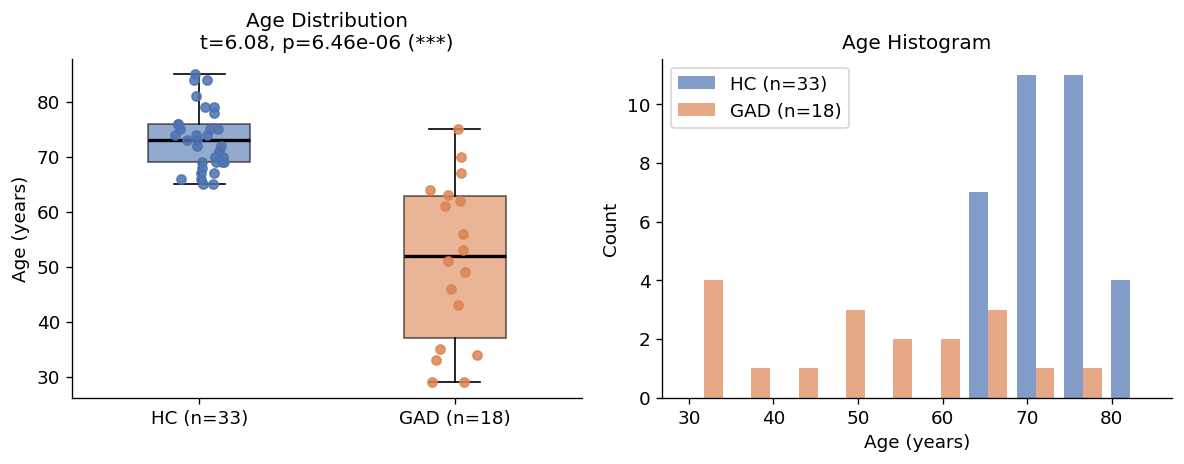

Saved: fig_age_comparison.png


In [5]:
hc_ages  = demo_hc['age'].dropna().astype(float)
gad_ages = demo_gad['age'].dropna().astype(float)

t_age, p_age = stats.ttest_ind(hc_ages, gad_ages, equal_var=False)  # Welch
df_age = len(hc_ages) + len(gad_ages) - 2

print('=== Age (years) ===')
print(f'HC   (n={len(hc_ages)})  : {hc_ages.mean():.1f} ± {hc_ages.std(ddof=1):.1f}  '
      f'(range {int(hc_ages.min())}–{int(hc_ages.max())})')
print(f'GAD  (n={len(gad_ages)}) : {gad_ages.mean():.1f} ± {gad_ages.std(ddof=1):.1f}  '
      f'(range {int(gad_ages.min())}–{int(gad_ages.max())})')
print(f"Welch's t-test  : t = {t_age:.3f},  p = {p_age:.4g}")

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes[0]
data_groups = [hc_ages.values, gad_ages.values]
bp = ax.boxplot(data_groups, patch_artist=True, widths=0.4,
                medianprops=dict(color='black', linewidth=2))
colors = ['#4C72B0', '#DD8452']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.6)
np.random.seed(0)
for i, (data, color) in enumerate(zip(data_groups, colors), 1):
    jitter = np.random.uniform(-0.1, 0.1, size=len(data))
    ax.scatter(np.full(len(data), i) + jitter, data, color=color, alpha=0.85, s=30, zorder=3)
ax.set_xticks([1, 2]); ax.set_xticklabels([f'HC (n={len(hc_ages)})', f'GAD (n={len(gad_ages)})'])
ax.set_ylabel('Age (years)')
stars = '***' if p_age < 0.001 else ('**' if p_age < 0.01 else ('*' if p_age < 0.05 else 'ns'))
ax.set_title(f'Age Distribution\nt={t_age:.2f}, p={p_age:.3g} ({stars})')

ax = axes[1]
ax.hist([hc_ages, gad_ages], bins=10, color=colors, alpha=0.7,
        label=[f'HC (n={len(hc_ages)})', f'GAD (n={len(gad_ages)})'])
ax.set_xlabel('Age (years)'); ax.set_ylabel('Count')
ax.set_title('Age Histogram'); ax.legend()

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_age_comparison.png'), bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: fig_age_comparison.png')


## 5. Sex Distribution

> **Excludes 11 demographics-missing GAD subjects** (see remark at top).

=== Sex Distribution ===
HC   (n=33) : F=23  (70%),  M=10  (30%)
GAD  (n=18) : F=14  (78%),  M=4  (22%)
Chi-square test    :  χ²(1) = 0.084,  p = 0.7721


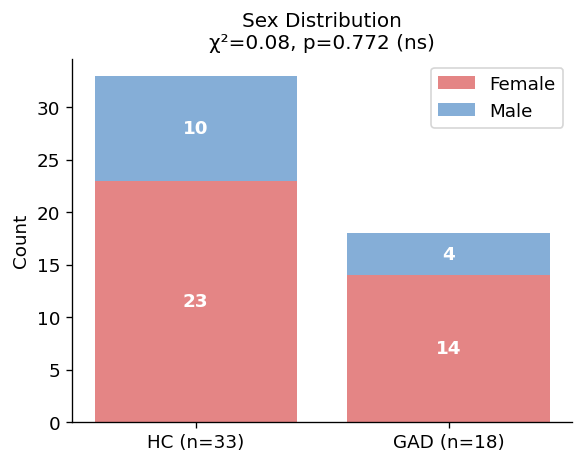

Saved: fig_sex_distribution.png


In [6]:
hc_f  = (demo_hc['gender']  == '女').sum()
hc_m  = (demo_hc['gender']  == '男').sum()
gad_f = (demo_gad['gender'] == '女').sum()
gad_m = (demo_gad['gender'] == '男').sum()

contingency = np.array([[hc_f, hc_m], [gad_f, gad_m]])
chi2_sex, p_sex, dof_sex, _ = chi2_contingency(contingency)

print('=== Sex Distribution ===')
print(f'HC   (n={hc_f+hc_m}) : F={hc_f}  ({hc_f/(hc_f+hc_m)*100:.0f}%),  M={hc_m}  ({hc_m/(hc_f+hc_m)*100:.0f}%)')
print(f'GAD  (n={gad_f+gad_m}) : F={gad_f}  ({gad_f/(gad_f+gad_m)*100:.0f}%),  M={gad_m}  ({gad_m/(gad_f+gad_m)*100:.0f}%)')
print(f'Chi-square test    :  χ²({dof_sex}) = {chi2_sex:.3f},  p = {p_sex:.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
groups = [f'HC (n={hc_f+hc_m})', f'GAD (n={gad_f+gad_m})']
females = [hc_f, gad_f]; males = [hc_m, gad_m]
x = np.arange(len(groups))
ax.bar(x, females, color='#E07070', alpha=0.85, label='Female')
ax.bar(x, males, bottom=females, color='#70A0D0', alpha=0.85, label='Male')
for i, (f, m) in enumerate(zip(females, males)):
    if f > 0: ax.text(i, f/2, f'{f}', ha='center', va='center', color='white', fontweight='bold')
    if m > 0: ax.text(i, f + m/2, f'{m}', ha='center', va='center', color='white', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylabel('Count')
stars = '*' if p_sex < 0.05 else 'ns'
ax.set_title(f'Sex Distribution\nχ²={chi2_sex:.2f}, p={p_sex:.3f} ({stars})')
ax.legend(loc='upper right')
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_sex_distribution.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_sex_distribution.png')


## 6. Education Distribution

> **Excludes 11 demographics-missing GAD subjects** (see remark at top).

=== Education ===
                    HC  GAD  HC_pct  GAD_pct
education                                   
Elementary           1    0     3.0      0.0
High School          8    5    24.2     29.4
University/College  21   11    63.6     64.7
Graduate+            3    1     9.1      5.9

Chi-square (collapsed, dof=3): χ² = 0.777, p = 0.8550


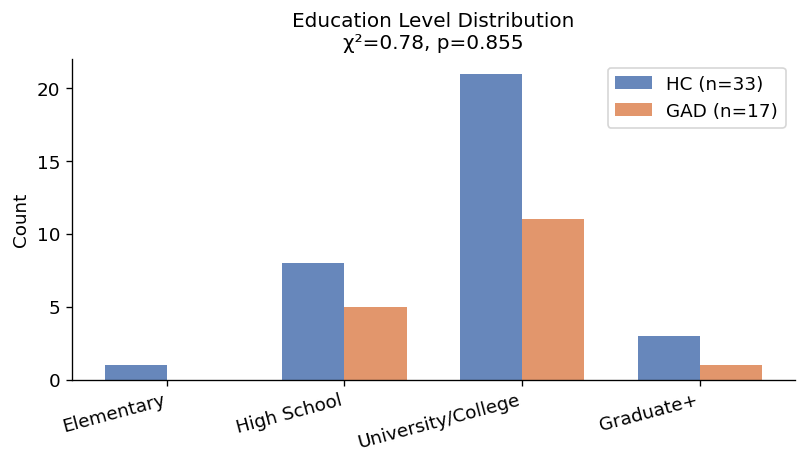

Saved: fig_education.png


In [7]:
edu_map = {
    '小學':       'Elementary',
    '高中/職':    'High School',
    '大學/專科':  'University/College',
    '研究所以上': 'Graduate+',
}
order = ['Elementary', 'High School', 'University/College', 'Graduate+']

hc_edu  = demo_hc['education'].map(edu_map).value_counts().reindex(order, fill_value=0)
gad_edu = demo_gad['education'].map(edu_map).value_counts().reindex(order, fill_value=0)

# Chi-square (collapse zero-count rows if needed)
edu_table = np.array([hc_edu.values, gad_edu.values])
keep = edu_table.sum(axis=0) > 0
chi2_edu, p_edu, dof_edu, _ = chi2_contingency(edu_table[:, keep])

print('=== Education ===')
edu_df = pd.DataFrame({'HC': hc_edu, 'GAD': gad_edu})
edu_df['HC_pct']  = (edu_df['HC']  / edu_df['HC'].sum()  * 100).round(1)
edu_df['GAD_pct'] = (edu_df['GAD'] / edu_df['GAD'].sum() * 100).round(1)
print(edu_df)
print(f"\nChi-square (collapsed, dof={dof_edu}): χ² = {chi2_edu:.3f}, p = {p_edu:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(order)); w = 0.35
ax.bar(x - w/2, hc_edu.values,  width=w, color='#4C72B0', alpha=0.85, label=f'HC (n={demo_hc["education"].notna().sum()})')
ax.bar(x + w/2, gad_edu.values, width=w, color='#DD8452', alpha=0.85, label=f'GAD (n={demo_gad["education"].notna().sum()})')
ax.set_xticks(x); ax.set_xticklabels(order, rotation=15, ha='right')
ax.set_ylabel('Count'); ax.set_title(f'Education Level Distribution\nχ²={chi2_edu:.2f}, p={p_edu:.3f}')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_education.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_education.png')


## 7. Marital Status & Occupation

> **Excludes 11 demographics-missing GAD subjects** (see remark at top).

In [8]:
def cat_compare(col, label, demo_hc=demo_hc, demo_gad=demo_gad):
    cats = sorted(set(demo_hc[col].dropna()) | set(demo_gad[col].dropna()))
    hc_counts  = demo_hc[col].value_counts().reindex(cats, fill_value=0)
    gad_counts = demo_gad[col].value_counts().reindex(cats, fill_value=0)
    table = np.array([hc_counts.values, gad_counts.values])
    keep = table.sum(axis=0) > 0
    if keep.sum() < 2:
        return None
    chi2, p, dof, _ = chi2_contingency(table[:, keep])
    df = pd.DataFrame({'HC': hc_counts, 'GAD': gad_counts})
    print(f'=== {label} ===')
    print(df)
    print(f'Chi-square: χ²({dof}) = {chi2:.3f}, p = {p:.4f}')
    print()
    return df, chi2, p

print()
cat_compare('marital_status', 'Marital Status')
cat_compare('occupation', 'Occupation')



=== Marital Status ===
                HC  GAD
marital_status         
分居               1    0
喪偶              11    0
單身且從未結過婚         1    5
已婚              15   12
離婚               5    0
Chi-square: χ²(4) = 16.578, p = 0.0023

=== Occupation ===
            HC  GAD
occupation         
全職           0   10
兼職           1    0
志工          12    0
無業／家管       20    7
Chi-square: χ²(3) = 26.893, p = 0.0000



(            HC  GAD
 occupation         
 全職           0   10
 兼職           1    0
 志工          12    0
 無業／家管       20    7,
 np.float64(26.893114148016107),
 np.float64(6.1990716482357345e-06))

## 8. HAMA — Hamilton Anxiety Rating Scale

> Uses **all 62 cohort subjects** (HAMA scores are populated for all GAD; healthy by definition = 0).
> LA063 (HAMA not administered → recorded as 0) is **excluded from the GAD HAMA mean** so as not to bias downward; the entry is reported in the table.

=== HAMA — GAD only (HC HAMA all 0 by definition) ===
GAD (n=28, LA063 excluded):  20.8 ± 9.1, range [7, 40], median=20
(HC n=33: by definition HAMA_sum=0 for all)

HAMA severity buckets (GAD, common cutoffs):
  mild (<18)    : n=10
  moderate (18-24): n=8
  severe (≥25)  : n=10


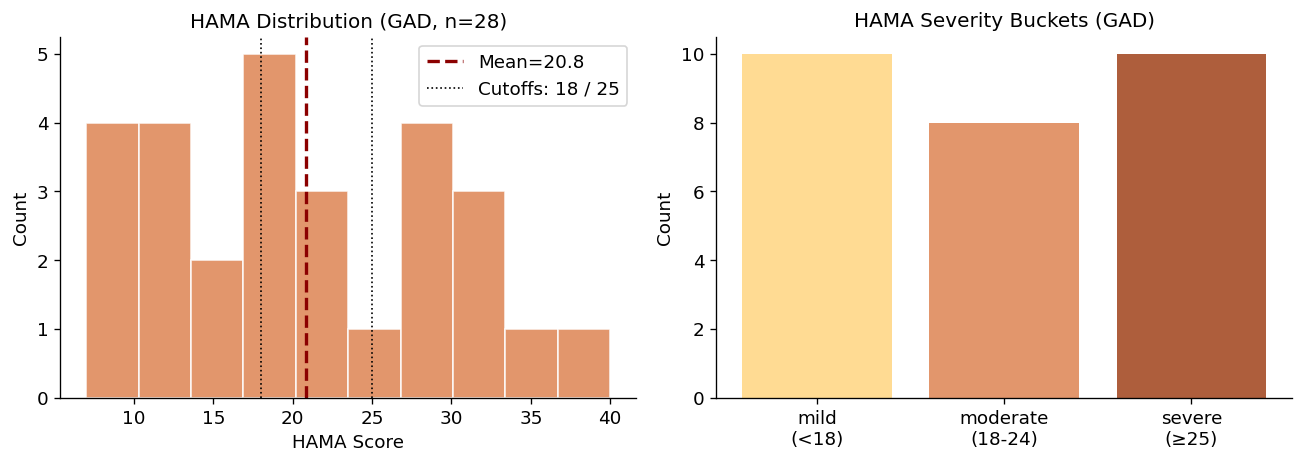

Saved: fig_hama_gad.png


In [9]:
la063_mask = scale_gad['subject_id'] == 'LA063'
hama_gad   = scale_gad.loc[~la063_mask, 'HAMA_sum'].astype(float)
hama_hc    = scale_hc['HAMA_sum'].astype(float)  # all 0 for HC

# HAMA distribution (GAD only, n=28 after LA063 exclusion)
print('=== HAMA — GAD only (HC HAMA all 0 by definition) ===')
print(f'GAD (n={len(hama_gad)}, LA063 excluded):  '
      f'{hama_gad.mean():.1f} ± {hama_gad.std(ddof=1):.1f}, '
      f'range [{int(hama_gad.min())}, {int(hama_gad.max())}], '
      f'median={hama_gad.median():.0f}')
print(f'(HC n={len(hama_hc)}: by definition HAMA_sum=0 for all)')
print(f'\nHAMA severity buckets (GAD, common cutoffs):')
mild = (hama_gad < 18).sum()
mod  = ((hama_gad >= 18) & (hama_gad < 25)).sum()
sev  = (hama_gad >= 25).sum()
print(f'  mild (<18)    : n={mild}')
print(f'  moderate (18-24): n={mod}')
print(f'  severe (≥25)  : n={sev}')

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.hist(hama_gad, bins=10, color='#DD8452', alpha=0.85, edgecolor='white')
ax.axvline(hama_gad.mean(), color='darkred', ls='--', lw=2, label=f'Mean={hama_gad.mean():.1f}')
ax.axvline(18, color='black', ls=':', lw=1, label='Cutoffs: 18 / 25')
ax.axvline(25, color='black', ls=':', lw=1)
ax.set_xlabel('HAMA Score'); ax.set_ylabel('Count')
ax.set_title(f'HAMA Distribution (GAD, n={len(hama_gad)})')
ax.legend()

ax = axes[1]
ax.bar(['mild\n(<18)','moderate\n(18-24)','severe\n(≥25)'],
       [mild, mod, sev], color=['#FFD580','#DD8452','#A0421A'], alpha=0.85)
ax.set_ylabel('Count'); ax.set_title('HAMA Severity Buckets (GAD)')

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_hama_gad.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_hama_gad.png')


## 9. STAI-S (State Anxiety) and STAI-T (Trait Anxiety)

> Uses **all 62 cohort subjects**.

=== STAI-S ===
HC   (n=33)  : 29.5 ± 8.4  (range 20–46)
GAD  (n=29) : 43.2 ± 11.9  (range 22–68)
Welch's t = -5.152, p = 4.447e-06, Cohen's d = 1.34

=== STAI-T ===
HC   (n=33)  : 33.9 ± 9.6  (range 20–62)
GAD  (n=29) : 54.2 ± 11.6  (range 28–75)
Welch's t = -7.459, p = 7.074e-10, Cohen's d = 1.92


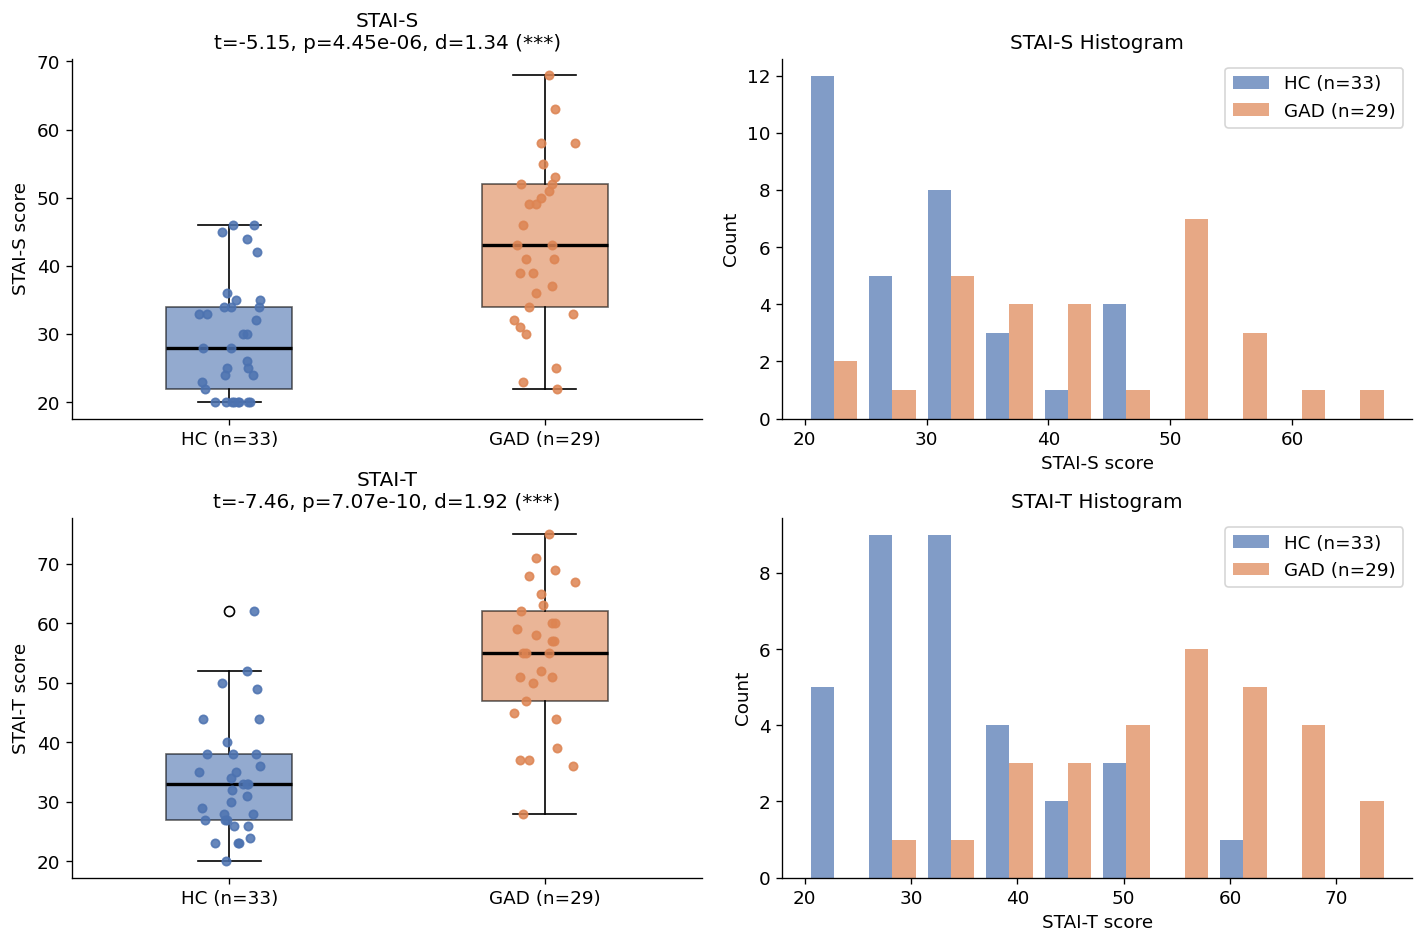

Saved: fig_stai_comparison.png


In [10]:
def stai_compare(col, label, ax_box, ax_hist, color_pair=('#4C72B0','#DD8452')):
    a = scale_hc[col].dropna().astype(float)
    b = scale_gad[col].dropna().astype(float)
    t, p = stats.ttest_ind(a, b, equal_var=False)
    df = len(a) + len(b) - 2
    pooled_sd = np.sqrt(((len(a)-1)*a.std(ddof=1)**2 + (len(b)-1)*b.std(ddof=1)**2) / df)
    d = abs(a.mean() - b.mean()) / pooled_sd
    print(f'=== {label} ===')
    print(f'HC   (n={len(a)})  : {a.mean():.1f} ± {a.std(ddof=1):.1f}  (range {int(a.min())}–{int(a.max())})')
    print(f'GAD  (n={len(b)}) : {b.mean():.1f} ± {b.std(ddof=1):.1f}  (range {int(b.min())}–{int(b.max())})')
    print(f"Welch's t = {t:.3f}, p = {p:.4g}, Cohen's d = {d:.2f}")

    bp = ax_box.boxplot([a.values, b.values], patch_artist=True, widths=0.4,
                        medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], color_pair):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    np.random.seed(0)
    for i, (data, color) in enumerate(zip([a.values, b.values], color_pair), 1):
        jitter = np.random.uniform(-0.1, 0.1, size=len(data))
        ax_box.scatter(np.full(len(data), i) + jitter, data, color=color, s=25, alpha=0.85, zorder=3)
    ax_box.set_xticks([1, 2])
    ax_box.set_xticklabels([f'HC (n={len(a)})', f'GAD (n={len(b)})'])
    ax_box.set_ylabel(f'{label} score')
    stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ax_box.set_title(f'{label}\nt={t:.2f}, p={p:.2e}, d={d:.2f} ({stars})')

    ax_hist.hist([a, b], bins=10, color=color_pair, alpha=0.7,
                 label=[f'HC (n={len(a)})', f'GAD (n={len(b)})'])
    ax_hist.set_xlabel(f'{label} score'); ax_hist.set_ylabel('Count')
    ax_hist.set_title(f'{label} Histogram'); ax_hist.legend()
    return t, p, d

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
stai_compare('STAIS_sum', 'STAI-S', axes[0,0], axes[0,1])
print()
stai_compare('STAIT_sum', 'STAI-T', axes[1,0], axes[1,1])
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_stai_comparison.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_stai_comparison.png')


## 10. Paper-Ready Summary Table & CSV Export

In [11]:
def fmt(x): return f'{x.mean():.1f} ± {x.std(ddof=1):.1f}'

rows = []
# Demographic block
rows.append(['Age (yrs, demographics-eligible)', f'{fmt(hc_ages)} (n={len(hc_ages)})', f'{fmt(gad_ages)} (n={len(gad_ages)})',
             f"t={t_age:.2f}", f"{p_age:.3g}"])
rows.append(['Sex F/M (demographics-eligible)', f'{hc_f}/{hc_m}', f'{gad_f}/{gad_m}', f'χ²={chi2_sex:.2f}', f'{p_sex:.3f}'])
rows.append(['Education χ² (demographics-eligible)', f'{demo_hc["education"].notna().sum()} reported',
             f'{demo_gad["education"].notna().sum()} reported', f'χ²={chi2_edu:.2f}', f'{p_edu:.3f}'])

# Anxiety scales (full cohort)
for col, lbl in [('STAIS_sum','STAI-S (full cohort)'), ('STAIT_sum','STAI-T (full cohort)')]:
    a = scale_hc[col].dropna(); b = scale_gad[col].dropna()
    t, p = stats.ttest_ind(a, b, equal_var=False)
    df_  = len(a) + len(b) - 2
    pooled_sd = np.sqrt(((len(a)-1)*a.std(ddof=1)**2 + (len(b)-1)*b.std(ddof=1)**2) / df_)
    d = abs(a.mean() - b.mean()) / pooled_sd
    rows.append([lbl, f'{fmt(a)} (n={len(a)})', f'{fmt(b)} (n={len(b)})', f"t={t:.2f}, d={d:.2f}", f'{p:.3g}'])

# HAMA (GAD only, LA063 excluded)
rows.append(['HAMA (GAD only, LA063 excluded)', '— (HC=0 by definition)',
             f'{fmt(hama_gad)} (n={len(hama_gad)})', '—', '—'])

summary = pd.DataFrame(rows, columns=['Variable', 'HC', 'GAD', 'Statistic', 'p-value'])
print(summary.to_string(index=False))

summary.to_csv(os.path.join(OUT_DIR, 'results_demographic_summary.csv'), index=False)
print(f'\nSaved: results_demographic_summary.csv')

# Also save the per-subject demographic frame for downstream use
per_subj = pd.concat([scale_hc.assign(group_label='HC'),
                      scale_gad.assign(group_label='GAD')], ignore_index=True)
per_subj.to_csv(os.path.join(OUT_DIR, 'cohort_per_subject.csv'), index=False)
print(f'Saved: cohort_per_subject.csv  (n={len(per_subj)})')

print(f'\n{"="*70}')
print('  REMARK')
print(f'{"="*70}')
print('Demographic statistics (age, sex, education, marital, occupation) exclude')
print('11 GAD subjects flagged demographics_missing=Y. Anxiety-scale statistics')
print('use the full GNG cohort (HC=33, GAD=29). HAMA mean excludes LA063.')


                            Variable                     HC                GAD       Statistic  p-value
    Age (yrs, demographics-eligible)      73.0 ± 5.6 (n=33) 51.1 ± 14.7 (n=18)          t=6.08 6.46e-06
     Sex F/M (demographics-eligible)                  23/10               14/4         χ²=0.08    0.772
Education χ² (demographics-eligible)            33 reported        17 reported         χ²=0.78    0.855
                STAI-S (full cohort)      29.5 ± 8.4 (n=33) 43.2 ± 11.9 (n=29) t=-5.15, d=1.34 4.45e-06
                STAI-T (full cohort)      33.9 ± 9.6 (n=33) 54.2 ± 11.6 (n=29) t=-7.46, d=1.92 7.07e-10
     HAMA (GAD only, LA063 excluded) — (HC=0 by definition)  20.8 ± 9.1 (n=28)               —        —

Saved: results_demographic_summary.csv
Saved: cohort_per_subject.csv  (n=62)

  REMARK
Demographic statistics (age, sex, education, marital, occupation) exclude
11 GAD subjects flagged demographics_missing=Y. Anxiety-scale statistics
use the full GNG cohort (HC=33, GAD=2